# Precalculo — ValorAuto

Toma el modelo Production desde MLflow, genera combinaciones marca/modelo/anio/km y calcula el precio de cada una, guardando el resultado en `data/precalc.db` (SQLite) de forma atomica. Notebook delgado: la logica vive en `src/pipeline/combinations.py` y `src/pipeline/precalculo.py` (ver [ADR-0008](../docs/adr/0008-separacion-componentes-notebooks-delgados.md)).

In [1]:
import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    """Busca la raiz del repo subiendo desde `start` hasta encontrar `src/` y `notebooks/`.

    No asume un cwd fijo (a diferencia de `Path.cwd().parent`, que solo
    funciona si el notebook se lanzo con cwd=notebooks/): sirve tanto si
    Jupyter arranca con cwd en la carpeta del notebook como si se ejecuta
    con nbconvert/papermill desde la raiz del repo u otra carpeta.
    """
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError(
        "No se pudo ubicar la raiz del repo (se buscaron 'src/' y 'notebooks/' "
        f"subiendo desde {start})."
    )


REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


In [2]:
from src.model import data_loading
from src.pipeline import combinations, precalculo


/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cargar el modelo Production y el dataset limpio

In [3]:
model = precalculo.cargar_modelo_production()
df_clean = data_loading.load_clean()
print("Modelo Production cargado.")


Modelo Production cargado.


## 2. Generar combinaciones y calcular precios

In [4]:
df_combinaciones = combinations.generar_combinaciones(df_clean)
print(f"Combinaciones a predecir: {len(df_combinaciones)}")

df_resultado = precalculo.calcular_precios(model, df_combinaciones)


Combinaciones a predecir: 78915


## 3. Guardar en SQLite (escritura atomica) y graficar el resumen

Base de precalculo escrita en: /app/data/precalc.db


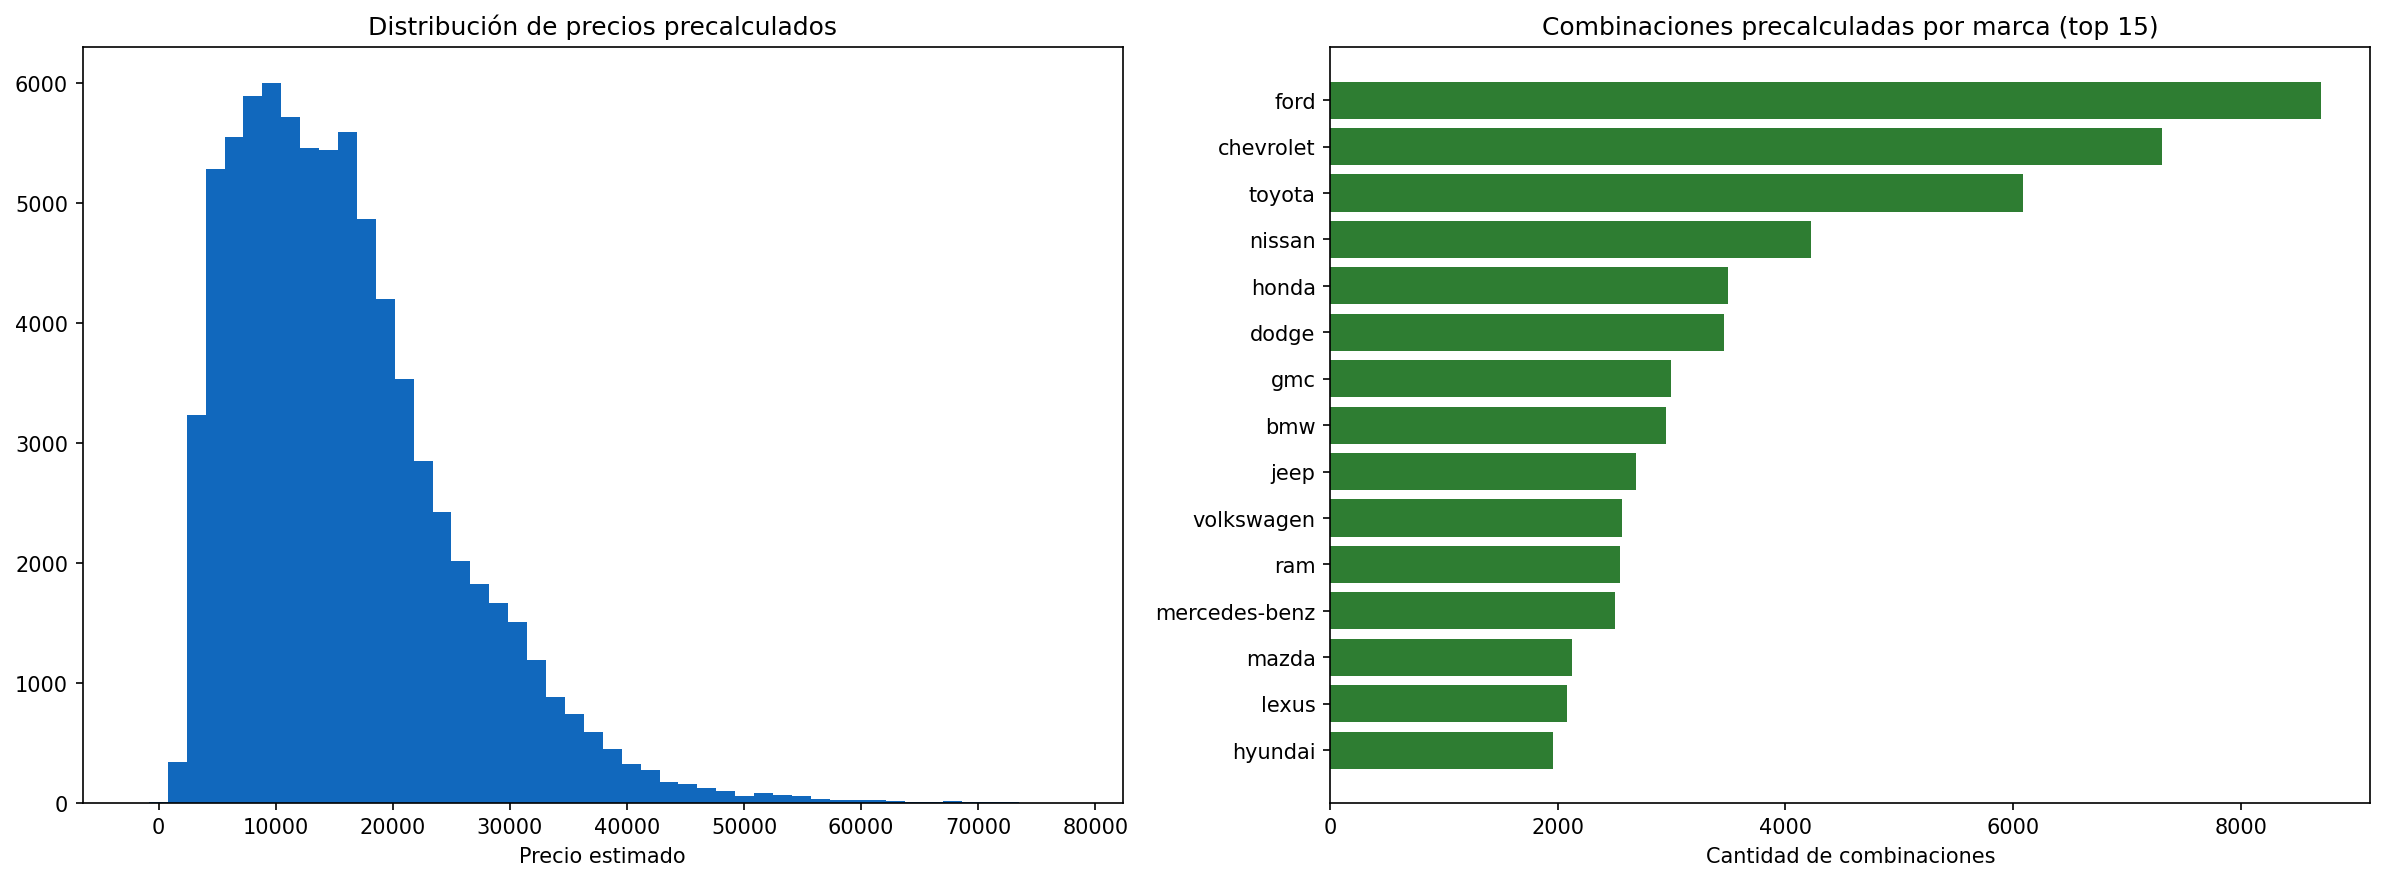

In [5]:
ruta_db = precalculo.guardar_sqlite(df_resultado)
print(f"Base de precalculo escrita en: {ruta_db}")

from IPython.display import Image, display
ruta_resumen = precalculo.graficar_resumen_precalculo(df_resultado)
display(Image(filename=ruta_resumen))
